### Step in depth antenna

A step in width microstrip antenna is a design variation where the radiating patch element has a non-uniform width that changes along its length. Instead of a simple rectangular patch, the conducting strip gradually narrows or widens at specific points.

In [1]:
import gmsh
import math
import os
import json

from palacetoolkit.viz import view_mesh
from palacetoolkit.mesh import (
    Entity, 
    run_meshing_pipeline, 
    generate_3d_mesh, 
    refine_near_surfaces
)

### Parameters:

- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- h : Patch height along z-axis, specified as a scalar in meters.

- strip_line_length : Notch length along x-axis, specified as a scalar in meters. 
- strip_lined_width_near_port: Notch width along x-axis near the port, specified as a scalar in meters. 
- strip_lined_width_far: Strip line width along y-axis far from the port, specified as a scalar in meters.
- air_height : Air box height along z-axis, specified as a scalar in meters.  
- air_margin : Air box margin along x and y axes, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.

In [2]:
l1: float = 0.06
w1: float = 0.06
strip_line_length: float = 0.06
strip_line_width_near_port: float = 0.001
strip_line_width_far: float = 0.003
h: float = 0.0013
air_height: float = 0.025    
air_margin: float = 0.025    
freq: float = 3.3
filename: str = "sw_antenna.msh"

wavelength = 3e8 / (freq * 1e9)

### Initialize the model

In [3]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ

### Geometry generation


In [4]:
# Total domain bounds
total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmax = h + air_height

substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)

ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

strip_line_1 = kernel.addRectangle(-l1/2, -strip_line_width_near_port/2, h, strip_line_length/2, strip_line_width_near_port)
strip_line_2 = kernel.addRectangle(0, -strip_line_width_far/2, h, strip_line_length/2, strip_line_width_far)

top_conductor, _ = kernel.fuse(
    [(2, strip_line_1)], [(2, strip_line_2)],
    removeObject=True, removeTool=True
)
kernel.synchronize()

gap = 0
lumped_port = kernel.addRectangle(-l1/2 + gap, -strip_line_width_near_port/2, 0, h - gap, strip_line_width_near_port)
kernel.rotate([(2, lumped_port)], -l1/2, 0, 0, 0, 1, 0, -math.pi/2)
kernel.synchronize()

air_box = kernel.addBox(
    total_xmin, total_ymin, 0,
    total_xmax - total_xmin,
    total_ymax - total_ymin,
    total_zmax
)
kernel.synchronize()

Info    : Cannot bind existing OpenCASCADE surface 8 to second tag 9
Info    : Could not preserve tag of 2D object 9 (->8)


### Entities definition

  Physical group 'air_box' (dim=3): pg=1, tags=[2]
  Physical group 'substrate' (dim=3): pg=2, tags=[1]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[8]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[7]
  Physical group 'lumped_port' (dim=2): pg=5, tags=[9]
  Physical group 'air_box__None' (dim=2): pg=6, tags=[17, 18, 19, 20, 21, 22]
  Physical group 'air_box__substrate' (dim=2): pg=7, tags=[10, 11, 13, 12, 14, 15, 16]
  ppw_near=50  ppw_far=30
  SizeMax=0.0030  transition=0.0227
  global: 8 curves, SizeMin=0.0018
  local (2, 9): 4 curves, SizeMin=0.0006
  Merged 2 fields with Min → field 5
[Entity('air_box', dim=3, order=2, tags=[2]), Entity('substrate', dim=3, order=1, tags=[1]), Entity('top_conductor', dim=2, order=1, tags=[8]), Entity('ground_plane', dim=2, order=1, tags=[7]), Entity('lumped_port', dim=2, order=0, tags=[9])]
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 32 (Line)
Info    : [ 10%] Meshing curve 33 (Line)
Info    : [ 10%] Meshing curve 34 (Line

Info    : [ 90%] Meshing surface 20 (Plane, MeshAdapt)
Info    : [ 90%] Meshing surface 21 (Plane, MeshAdapt)
Info    : [100%] Meshing surface 22 (Plane, MeshAdapt)
Info    : Done meshing 2D (Wall 0.273954s, CPU 0.272651s)
Info    : Meshing 3D...
Info    : 3D Meshing 2 volumes with 1 connected component
Info    : Tetrahedrizing 6423 nodes...
Info    : Done tetrahedrizing 6431 nodes (Wall 0.0671928s, CPU 0.0622s)
Info    : Reconstructing mesh...


Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.186215s, CPU 0.17138s)
Info    : Found volume 2
Info    : Found volume 1
Info    : It. 0 - 0 nodes created - worst tet radius 11.9517 (nodes removed 0 0)


Info    : It. 500 - 500 nodes created - worst tet radius 2.29033 (nodes removed 0 0)
Info    : It. 1000 - 1000 nodes created - worst tet radius 1.86764 (nodes removed 0 0)
Info    : It. 1500 - 1500 nodes created - worst tet radius 1.6674 (nodes removed 0 0)
Info    : It. 2000 - 2000 nodes created - worst tet radius 1.53717 (nodes removed 0 0)
Info    : It. 2500 - 2500 nodes created - worst tet radius 1.44211 (nodes removed 0 0)
Info    : It. 3000 - 3000 nodes created - worst tet radius 1.359 (nodes removed 0 0)
Info    : It. 3500 - 3500 nodes created - worst tet radius 1.29288 (nodes removed 0 0)
Info    : It. 4000 - 4000 nodes created - worst tet radius 1.24093 (nodes removed 0 0)


Info    : It. 4500 - 4500 nodes created - worst tet radius 1.19871 (nodes removed 0 0)
Info    : It. 5000 - 5000 nodes created - worst tet radius 1.16311 (nodes removed 0 0)
Info    : It. 5500 - 5500 nodes created - worst tet radius 1.13059 (nodes removed 0 0)
Info    : It. 6000 - 6000 nodes created - worst tet radius 1.10171 (nodes removed 0 0)
Info    : It. 6500 - 6500 nodes created - worst tet radius 1.07612 (nodes removed 0 0)
Info    : It. 7000 - 7000 nodes created - worst tet radius 1.05259 (nodes removed 0 0)
Info    : It. 7500 - 7500 nodes created - worst tet radius 1.0303 (nodes removed 0 0)


...

Info    : 214 swaps performed 
Info    : SwapImprove2  


Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 78441.5 
Info    : Total badness = 78309.5 
Info    : Done optimizing mesh (Wall 4.89742s, CPU 4.90603s)
Info    : Writing 'sw_antenna.msh'...


Mesh saved to sw_antenna.mshInfo    : Done writing 'sw_antenna.msh'

  Nodes: 14580
  Elements: 83588


Loading mesh file: sw_antenna.msh
Groups to render transparent: air_box__None



Mesh loaded successfully with 2 cell blocks
Found 12943 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port', 6: 'air_box__None', 7: 'air_box__substrate'}



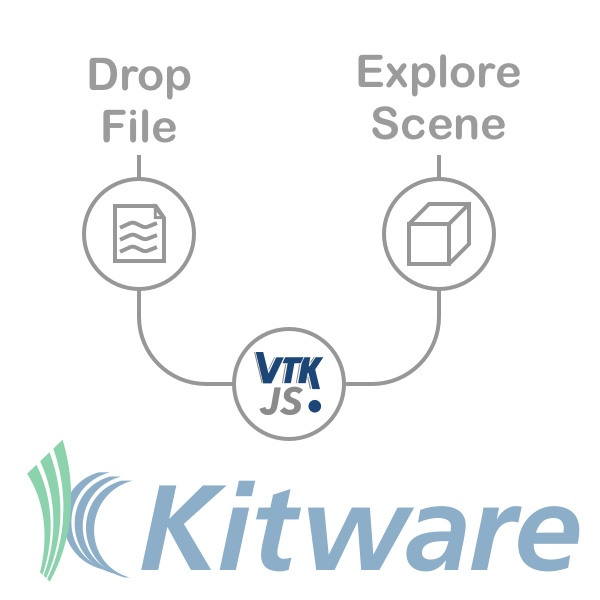

In [5]:
entities = [
    Entity("air_box", dim = 3, mesh_order = 2, tags = [air_box]),
    Entity("substrate", dim = 3, mesh_order = 1, tags = [substrate]),
    Entity("top_conductor", dim = 2, mesh_order= 1, tags = [top_conductor[0][1]]),
    Entity("ground_plane", dim = 2, mesh_order = 1, tags = [ground_plane]),
    Entity("lumped_port", dim = 2, mesh_order = 0, tags = [lumped_port])
]

pg_map = run_meshing_pipeline(entities)

# Refine near the top conductor and locally the lumped port
refine_near_surfaces(entities[2].dimtags, 
                     wavelength, 
                     ppw_near=50, 
                     ppw_far=30, 
                     set_as_background=True,
                     local_refinements = {entities[-1].dimtags[0]: 150})

print(entities)

# Mesh sizes
mesh_sizes = {
    "substrate": wavelength / 12,
    "air_box": wavelength / 4,
    "lumped_port": wavelength / 150,
    "ground_plane" : wavelength / 10,
    "top_conductor": wavelength / 50
}

generate_3d_mesh(entities, mesh_sizes, filename, optimize = True)

view_mesh(filename, transparent_groups="air_box__None")

### Generate JSON config


In [6]:
output_file: str = "sw_antenna.json"
freq_min: float = 3.0
freq_max: float = 3.5
freq_step: float = 0.005
eps_r: float = 2.2
loss_tan: float = 0.0009
port_impedance: float = 50.0
solver_order: int = 2

In [7]:
def attr(name):
        return [pg_map[name]] if name in pg_map else []

config = {
    "Problem": {
        "Type": "Driven",
        "Verbose": 2,
        "Output": "/work/results/sw_antenna/"
    },

    "Model": {
        "Mesh": f"/work/{filename}",
        "L0": 1.0,
        "Refinement": {}
    },

    "Domains": {
        "Materials": [
            {
                "Attributes": attr("substrate"),
                "Permittivity": eps_r,
                "Permeability": 1.0,
                "LossTan": loss_tan
            },
            {
                "Attributes": attr("air"),
                "Permittivity": 1.0,
                "Permeability": 1.0
            }
        ]
    },

    "Boundaries": {
        "PEC": {
            "Attributes": attr("ground_plane") + attr("patch")
        },

        "LumpedPort": [
            {
                "Index": 1,
                "Attributes": attr("lumped_port"),
                "R": port_impedance,
                "Excitation": True,
                "Direction": "+Z"
            }
        ],

        "Absorbing": {
            "Attributes": attr("farfield"),
            "Order": 1
        }
    },

    "Solver": {
        "Order": solver_order,
        "Device": "CPU",

        "Driven": {
            "MinFreq": freq_min,
            "MaxFreq": freq_max,
            "FreqStep": freq_step,
            "AdaptiveTol": 0.001
        },

        "Linear": {
            "Type": "Default",
            "KSPType": "GMRES",
            "Tol": 1.0e-8,
            "MaxIts": 200,
            "ComplexCoarseSolve": True
        }
    }
}

script_dir = os.getcwd()
config_path = os.path.join(script_dir, output_file)
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Palace config written to {config_path}")

Palace config written to /home/martin/Desktop/PalaceToolkit/docs/examples/sw_antenna.json
